In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import joblib
import seaborn as sns

In [242]:
df=pd.read_csv('/content/Cleaned_data.csv')

In [243]:
df.head()

,Unnamed: 0,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,...,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI,TrainingLevel,Sleep_Category,Matches_Load,Injury_History,Nutrition_Category,Injury_Status
0,0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,...,81.472206,1,0,21.383942,High,Normal,Very High,Few Injuries,Good,No Injury
1,1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,...,81.056677,1,0,23.183391,High,Normal,Very High,Few Injuries,Good,No Injury
2,2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,...,64.877457,0,1,21.678807,High,Normal,Low,Few Injuries,Average,Injured
3,3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,...,89.824744,1,0,20.957274,Moderate,Normal,Low,Few Injuries,Good,No Injury
4,4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,...,71.569197,0,1,31.773932,High,Poor,Low,Few Injuries,Average,Injured


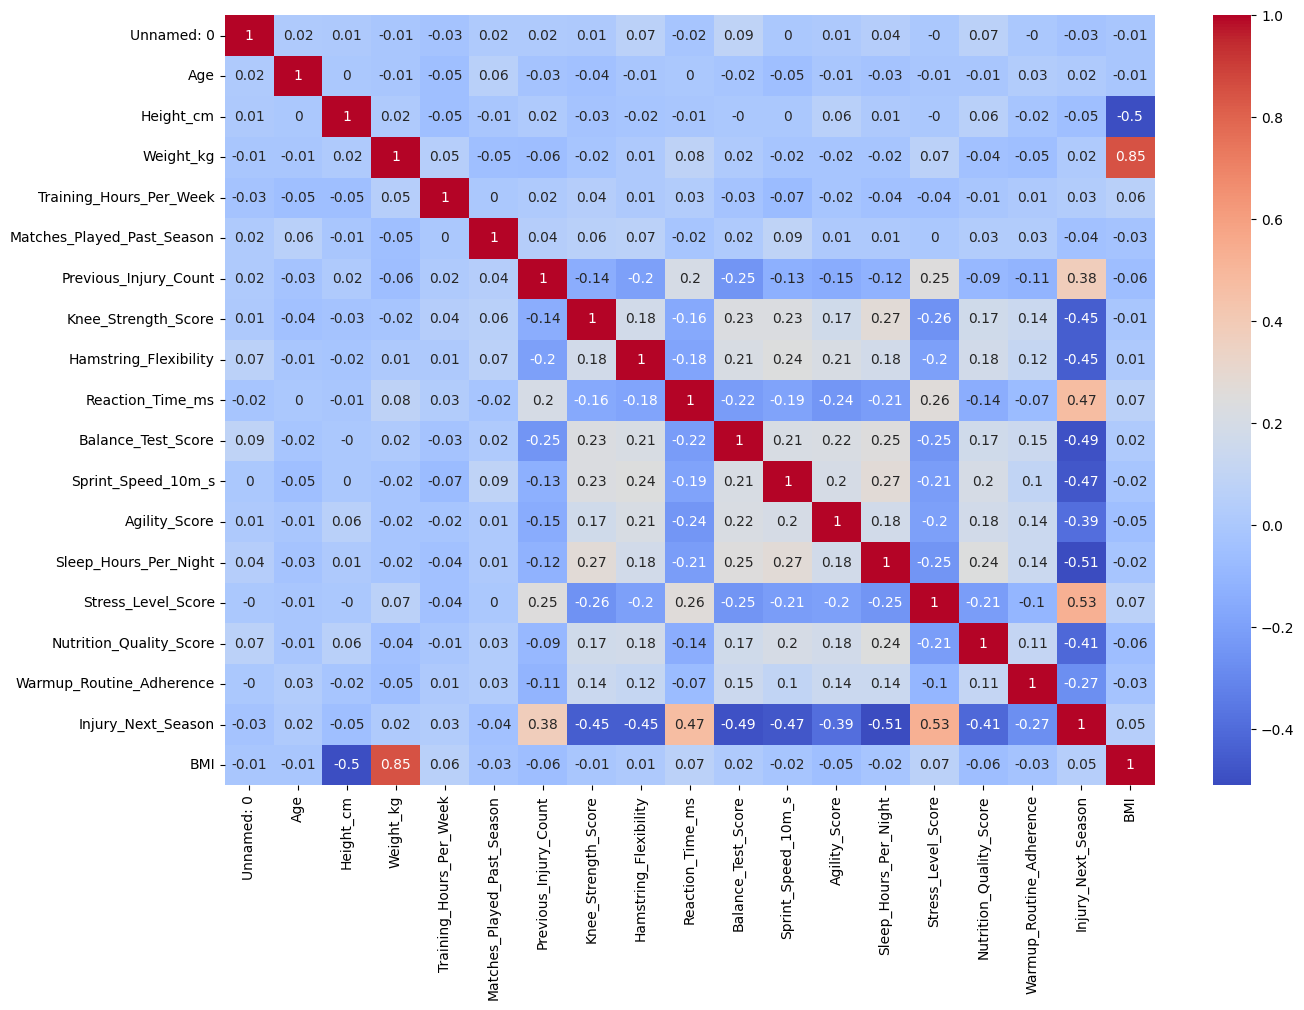

In [244]:
#heatmap for correlations
cor= df.select_dtypes(include='number').corr().round(2)
plt.figure(figsize=(15,10))
sns.heatmap(cor,annot=True,cmap="coolwarm")
plt.show()

In [245]:
# label encoding for category column
le = LabelEncoder()
df["Position"] = le.fit_transform(df["Position"])

In [246]:
# choose only the columns that affects on the target (we know them from the heatmap(corr))
X=df[["Stress_Level_Score","Sleep_Hours_Per_Night","Balance_Test_Score","Reaction_Time_ms",
    "Sprint_Speed_10m_s","Knee_Strength_Score","Hamstring_Flexibility","Nutrition_Quality_Score","Agility_Score",
    "Previous_Injury_Count","Warmup_Routine_Adherence","Position"]]
y=df['Injury_Next_Season']

In [247]:
#split the data
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=45)

In [248]:
s=StandardScaler()

In [249]:
# scailing numeric colummns
x_train_s=s.fit_transform(x_train)
x_test_s=s.fit_transform(x_test)

In [250]:
k_values=[1,3,5,7,9,11,13,15]
best_k,best_acc=None,0

In [251]:
#find best K
for k in k_values:
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(x_train_s,y_train)
  y_pred=model.predict(x_test_s)
  acc=accuracy_score(y_test,y_pred)
  print(f"K={k} --> Accuracy :{acc}")
  if acc>best_acc:
    best_acc,best_k=acc,k
print(best_acc,best_k)

K=1 --> Accuracy :0.9166666666666666
K=3 --> Accuracy :0.9416666666666667
K=5 --> Accuracy :0.95
K=7 --> Accuracy :0.9458333333333333
K=9 --> Accuracy :0.9458333333333333
K=11 --> Accuracy :0.9541666666666667
K=13 --> Accuracy :0.95
K=15 --> Accuracy :0.95
0.9541666666666667 11


In [252]:
# final model
final_model=KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train_s,y_train)
y_pred=final_model.predict(x_test_s)
acc=accuracy_score(y_test,y_pred)

In [253]:
acc

0.9541666666666667

In [254]:
confusion_matrix(y_test,y_pred)

array([[113,   1],
       [ 10, 116]])

In [255]:
#save the model and preprocessing steps
joblib.dump(final_model,"injury_model.pkl")
joblib.dump(le,"label_encoder.pkl")
joblib.dump(s,"scaler.pkl")

['scaler.pkl']

## Model Deployment

In [256]:
import sys
# Install Gradio
!{sys.executable} -m pip install gradio -q

In [257]:
import gradio as gr
import joblib


# Load the saved model and preprocessing steps
final_model = joblib.load('injury_model.pkl')
le = joblib.load('label_encoder.pkl')
s = joblib.load('scaler.pkl')
# Define the important features
expected_features = [
    'Stress_Level_Score', 'Sleep_Hours_Per_Night', 'Balance_Test_Score',
    'Reaction_Time_ms', 'Sprint_Speed_10m_s', 'Knee_Strength_Score',
    'Hamstring_Flexibility', 'Nutrition_Quality_Score', 'Agility_Score',
    'Previous_Injury_Count', 'Warmup_Routine_Adherence', 'Position'
]
def predict_injury(stress_level, sleep_hours, balance_score, reaction_time, sprint_speed,
                   knee_strength, hamstring_flex, nutrition_quality, agility_score,
                   previous_injury_count, warmup_adherence, position):
    # Create a DataFrame from the input
    input_data = {
        'Stress_Level_Score': stress_level,
        'Sleep_Hours_Per_Night': sleep_hours,
        'Balance_Test_Score': balance_score,
        'Reaction_Time_ms': reaction_time,
        'Sprint_Speed_10m_s': sprint_speed,
        'Knee_Strength_Score': knee_strength,
        'Hamstring_Flexibility': hamstring_flex,
        'Nutrition_Quality_Score': nutrition_quality,
        'Agility_Score': agility_score,
        'Previous_Injury_Count': previous_injury_count,
        'Warmup_Routine_Adherence': warmup_adherence,
        'Position': position
    }
    input_df = pd.DataFrame([input_data])
    # Label Encode 'Position'
    input_df['Position'] = le.transform([str(input_df['Position'].iloc[0])])
    # Scale numerical features
    input_scaled = s.transform(input_df[expected_features])
    # Make prediction
    prediction = final_model.predict(input_scaled)[0]
    prediction_proba = final_model.predict_proba(input_scaled)[0]
    # get the injury_probability
    injury_probability = prediction_proba[1] * 100
    # Map prediction to meaningful labels
    prediction_label = 'Injured' if prediction == 1 else 'No Injury'
    # result printed
    if prediction == 1:
        result = f"⚠️ High Injury Risk! (Predicted: {prediction_label})\nProbability of Injury: {injury_probability:.1f}%"
    else:
        result = f"✅ Low Injury Risk (Predicted: {prediction_label})\nProbability of Injury: {injury_probability:.1f}%"
    return result

In [258]:
# Create Gradio interface
interface = gr.Interface(
    fn=predict_injury,
    inputs=[
        gr.Slider(minimum=0, maximum=100, label='Stress Level Score'),
        gr.Slider(minimum=4, maximum=12, label='Sleep Hours Per Night'),
        gr.Slider(minimum=0, maximum=100, label='Balance Test Score'),
        gr.Slider(minimum=150, maximum=400, label='Reaction Time (ms)'),
        gr.Slider(minimum=1, maximum=10, label='Sprint Speed 10m (s)'),
        gr.Slider(minimum=0, maximum=100, label='Knee Strength Score'),
        gr.Slider(minimum=0, maximum=100, label='Hamstring Flexibility'),
        gr.Slider(minimum=0, maximum=100, label='Nutrition Quality Score'),
        gr.Slider(minimum=0, maximum=100, label='Agility Score'),
        gr.Slider(minimum=0, maximum=10, step=1, label='Previous Injury Count'),
        gr.Radio([0, 1], label='Warmup Routine Adherence (0=No, 1=Yes)'),
        gr.Dropdown(le.classes_.tolist(), label='Position') # Use actual classes from LabelEncoder
    ],
    outputs='text',
    title='Player Injury Prediction',
    description='Enter player details to predict the likelihood of injury next season.'
)
# Launch the interface with a public share link
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9fbec194ec30b34035.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### How to Use the Gradio Deployment

1.  **Run the cells above.** After the last cell (`interface.launch(share=True)`) executes, a Gradio interface will appear directly in the Colab output cell.
2.  **Look for the public URL.** Below the interface, you will see a public shareable URL (e.g., `Running on public URL: https://xxxx.gradio.app`). This link will be active for 72 hours.
3.  **Interact with the UI.** You can use the sliders, radio buttons, and dropdowns in the interface to input player data and get predictions.

This Gradio link provides a user-friendly interface directly, rather than just an API endpoint.